## Grafici di confronto tra FWHM delle righe di emissione e masse ottenute da MCMC con diverse prior 

# 1° Tipo di grafici

Ho confrontato le masse ottenute dai tre modelli MCMC:
- SS con prior uniforme,
- ADAF con prior uniforme,
- modello con prior gaussiana.

Per ogni blazar sono state associate le FWHM delle linee di emissione valide (flag = 0) alle masse mediane ottenute dai fit. Nel grafico:
- l’asse x rappresenta la FWHM,
- l’asse y la massa del buco nero,
- il colore identifica la linea di emissione,
- la forma del marker distingue il modello MCMC utilizzato.

L’obiettivo è verificare se esista una dipendenza dei risultati MCMC dalla riga di emissione considerata e confrontare il comportamento dei diversi modelli di accrescimento.

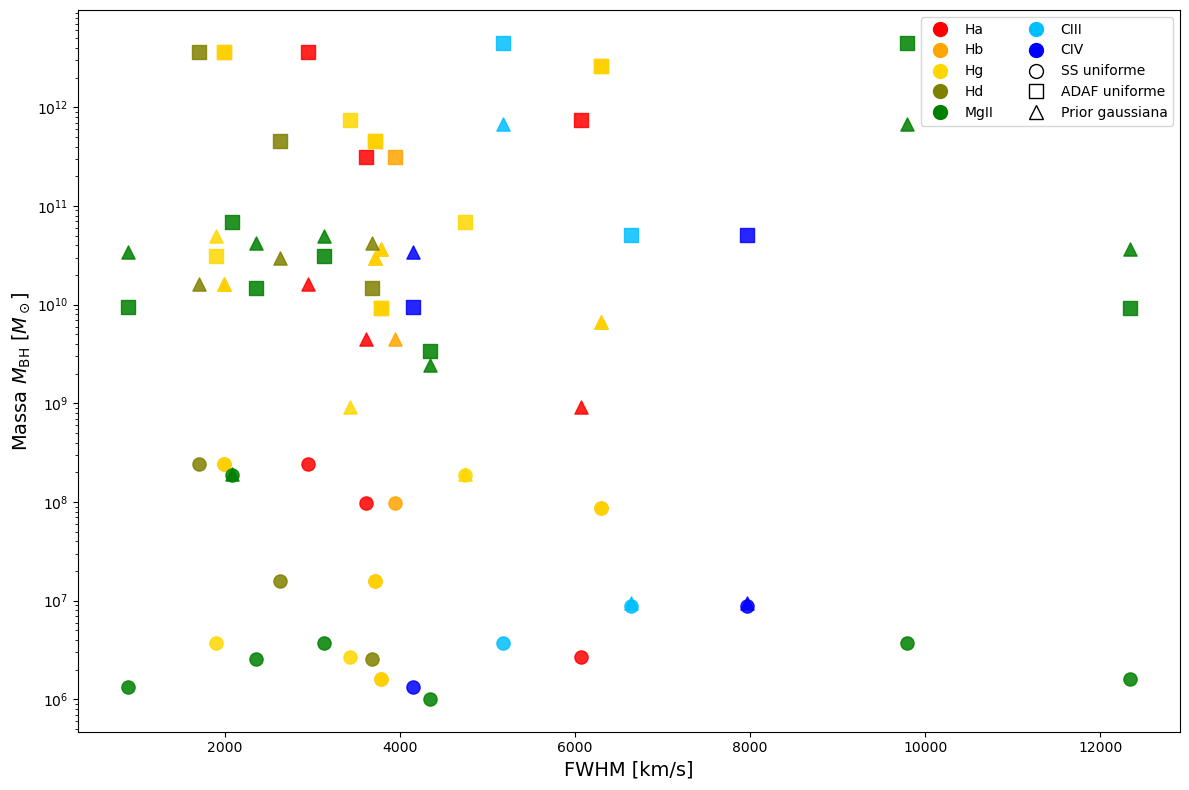

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =========================
# INPUT
# =========================
file_tabella = "Tab_completa_revisione.csv"

# =========================
# MASSE MCMC
# =========================
masse = {
    "J0021":   {"SS": 1.573e7,  "ADAF": 4.588e11, "GAUSS": 2.937e10},
    "J0050":   {"SS": 2.655e6,  "ADAF": 7.393e11, "GAUSS": 9.262e8},
    "J0059":   {"SS": 1.880e8,  "ADAF": 6.922e10, "GAUSS": 1.918e8},
    "J0133":   {"SS": 2.535e6,  "ADAF": 1.461e10, "GAUSS": 4.215e10},
    "J0508":   {"SS": 8.762e6,  "ADAF": 5.078e10, "GAUSS": 9.543e6},
    "J0922":   {"SS": 1.590e6,  "ADAF": 9.168e9,  "GAUSS": 3.623e10},
    "J1123":   {"SS": 2.445e8,  "ADAF": 3.671e12, "GAUSS": 1.608e10},
    "J1329":   {"SS": 3.705e6,  "ADAF": 3.130e10, "GAUSS": 4.973e10},
    "J1745":   {"SS": 9.694e7,  "ADAF": 3.124e11, "GAUSS": 4.453e9},
    "J1816":   {"SS": 1.337e6,  "ADAF": 9.402e9,  "GAUSS": 3.430e10},
    "J2237":   {"SS": 8.691e7,  "ADAF": 2.633e12, "GAUSS": 6.712e9},
    "J152422": {"SS": 3.748e6,  "ADAF": 4.501e12, "GAUSS": 6.758e11},
    "J170108": {"SS": 1.010e6,  "ADAF": 3.421e9,  "GAUSS": 2.472e9},
}

# =========================
# LETTURA CSV
# =========================
df = pd.read_csv(file_tabella)

df["label_short"] = (
    df["label"]
    .astype(str)
    .str.extract(r"(J\d+)")[0]
)

# =========================
# COLORI LINEE
# =========================
color_map_linea = {
    "Ha": "red",
    "Hb": "orange",
    "Hg": "gold",
    "Hd": "olive",
    "MgII": "green",
    "CIII": "deepskyblue",
    "CIV": "blue"
}

# =========================
# MARKER MODELLI
# =========================
marker_modelli = {
    "SS": "o",
    "ADAF": "s",
    "GAUSS": "^"
}

label_modelli = {
    "SS": "SS uniforme",
    "ADAF": "ADAF uniforme",
    "GAUSS": "Prior gaussiana"
}

# =========================
# RIGHE
# =========================
righe = ["Ha", "Hb", "Hg", "Hd", "MgII", "CIII", "CIV"]

records = []

for _, row in df.iterrows():

    blazar = row["label_short"]

    if blazar not in masse:
        continue

    for linea in righe:

        col_fwhm = f"{linea}_fwhm"
        col_flag = f"{linea}_flag"

        if col_fwhm not in df.columns:
            continue

        if col_flag not in df.columns:
            continue

        fwhm = row[col_fwhm]
        flag = row[col_flag]

        if (
            flag == 0
            and np.isfinite(fwhm)
            and fwhm > 0
        ):

            records.append({
                "blazar": blazar,
                "linea": linea,
                "fwhm": fwhm,
                "SS": masse[blazar]["SS"],
                "ADAF": masse[blazar]["ADAF"],
                "GAUSS": masse[blazar]["GAUSS"],
            })

df_plot = pd.DataFrame(records)

# =========================
# PLOT
# =========================
fig, ax = plt.subplots(figsize=(12, 8))

for _, row in df_plot.iterrows():

    linea = row["linea"]
    colore = color_map_linea[linea]

    for modello in ["SS", "ADAF", "GAUSS"]:

        ax.scatter(
            row["fwhm"],
            row[modello],
            color=colore,
            marker=marker_modelli[modello],
            s=90,
            alpha=0.85
        )

# =========================
# ASSI
# =========================
ax.set_yscale("log")

ax.set_xlabel(
    "FWHM [km/s]",
    fontsize=14
)

ax.set_ylabel(
    r"Massa $M_{\rm BH}$ [$M_\odot$]",
    fontsize=14
)


# =========================
# LEGENDA COLORI
# =========================
legend_colori = []

for linea, colore in color_map_linea.items():

    legend_colori.append(
        Line2D(
            [0],
            [0],
            marker='o',
            color='w',
            markerfacecolor=colore,
            markersize=10,
            label=linea
        )
    )

# =========================
# LEGENDA FORME
# =========================
legend_elements = []

# ---- prima colori (linee)
for linea, colore in color_map_linea.items():

    legend_elements.append(
        Line2D(
            [0],
            [0],
            marker='o',
            color='w',
            markerfacecolor=colore,
            markeredgecolor=colore,
            markersize=10,
            linestyle='None',
            label=linea
        )
    )

# ---- poi forme (modelli)
for modello, marker in marker_modelli.items():

    legend_elements.append(
        Line2D(
            [0],
            [0],
            marker=marker,
            color='black',
            markerfacecolor='none',
            markeredgecolor='black',
            markersize=10,
            linestyle='None',
            label=label_modelli[modello]
        )
    )

# legenda finale
ax.legend(
    handles=legend_elements,
    loc="best",
    fontsize=10,
    ncol=2,
    frameon=True
)

plt.tight_layout()
plt.show()

OSS : il modello domina molto più della riga : M_ADAF ​>> M_Gauss ​>> M_SS​

OSS : le righe ad alta ionizzazione (soprattutto CIV blu e in parte CIII azzurro) tendono a stare a FWHM più alte;   MgII (verde) occupa una fascia molto ampia di FWHM ma con forte dispersione di massa;   le Balmer (Ha, Hb, Hg, Hd) stanno più concentrate tra ~2000–7000 km/s.

# 2° Tipo di grafici

Ho confrontato le masse ottenute tramite MCMC utilizzando:
- prior uniforme,
- prior gaussiana con separazione dei regimi SS e ADAF.

Per ogni blazar sono state associate le FWHM delle linee di emissione valide (flag = 0) alle masse mediane ottenute dai fit. Nei grafici:
- l’asse x rappresenta la FWHM,
- l’asse y la massa del buco nero,
- il colore identifica la linea di emissione,
- la forma del marker distingue il tipo di prior.

L’obiettivo è verificare se il comportamento dei fit MCMC dipenda dalla riga considerata e confrontare i risultati ottenuti nei regimi SS e ADAF.

     blazar linea          fwhm  SS_uniforme  ADAF_uniforme  \
0     J1745    Ha   3608.538099   96940000.0   3.124000e+11   
1     J1745    Hb   3941.165547   96940000.0   3.124000e+11   
2     J0021    Hb   3714.135371   15730000.0   4.588000e+11   
3     J0021    Hg   3714.135371   15730000.0   4.588000e+11   
4     J0021    Hd   2625.417509   15730000.0   4.588000e+11   
5     J0050    Ha   6067.392036    2655000.0   7.393000e+11   
6     J0050    Hg   3427.991173    2655000.0   7.393000e+11   
7     J0508  CIII   6641.644798    8762000.0   5.078000e+10   
8     J0508   CIV   7963.603339    8762000.0   5.078000e+10   
9     J0922    Hb   3784.714319    1590000.0   9.168000e+09   
10    J0922    Hg   3784.714319    1590000.0   9.168000e+09   
11    J0922  MgII  12338.591519    1590000.0   9.168000e+09   
12    J1123    Ha   2955.558000  244500000.0   3.671000e+12   
13    J1123    Hb   1992.931925  244500000.0   3.671000e+12   
14    J1123    Hg   1992.931925  244500000.0   3.671000

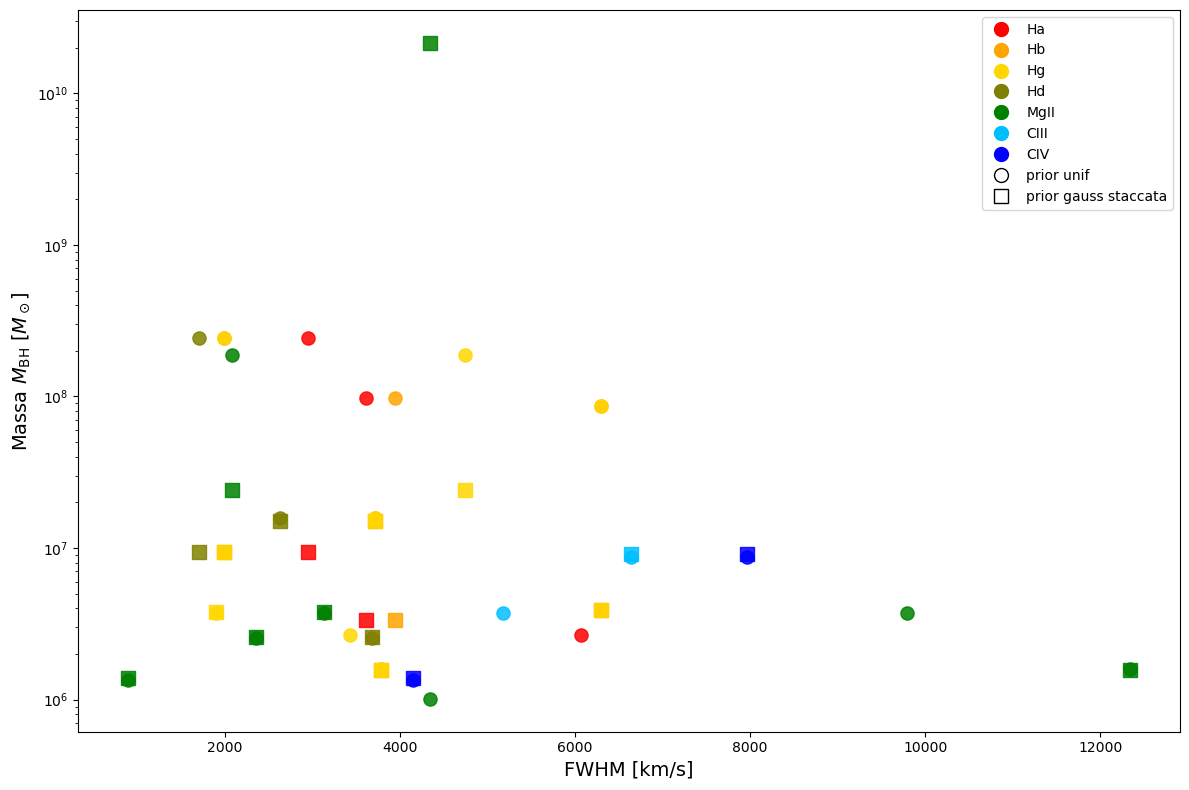

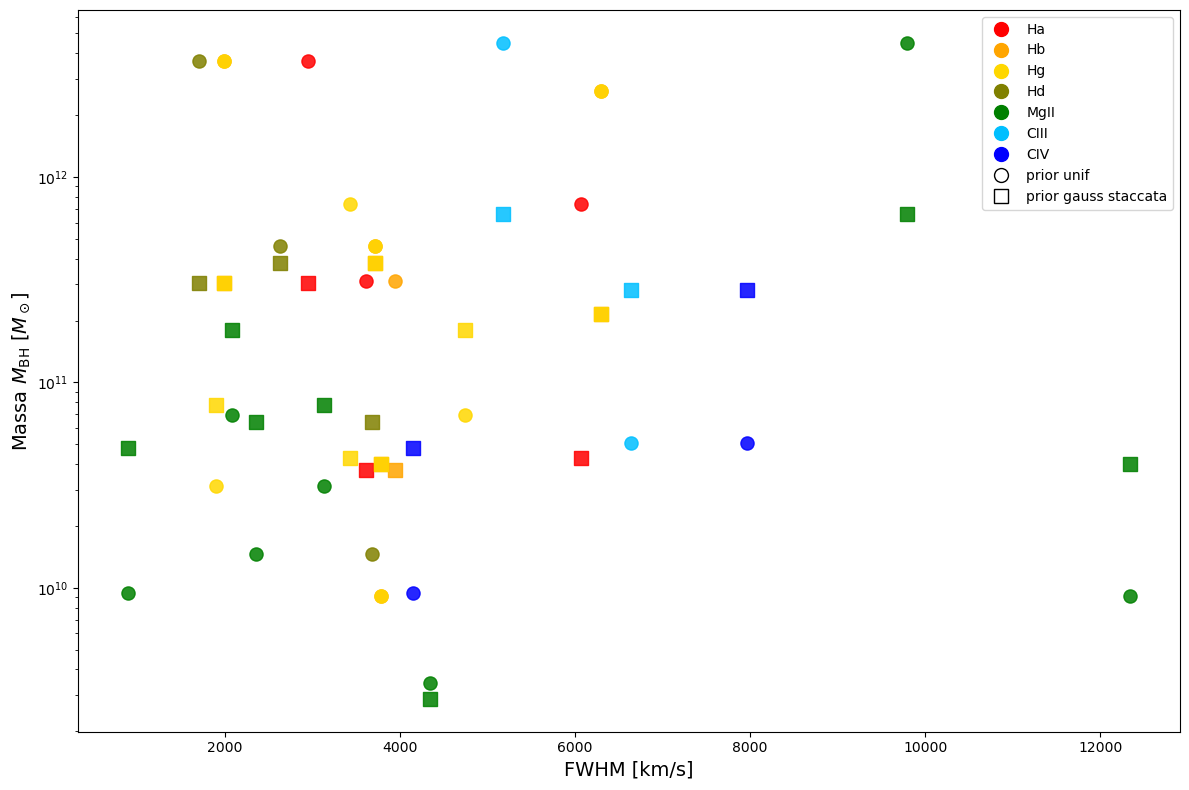

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ==========================================================
# INPUT
# ==========================================================
file_tabella = "Tab_completa_revisione.csv"

# ==========================================================
# MASSE MCMC: PRIOR UNIFORME
# ==========================================================
masse_uniforme = {
    "J0021":   {"SS": 1.573e7,  "ADAF": 4.588e11},
    "J0050":   {"SS": 2.655e6,  "ADAF": 7.393e11},
    "J0059":   {"SS": 1.880e8,  "ADAF": 6.922e10},
    "J0133":   {"SS": 2.535e6,  "ADAF": 1.461e10},
    "J0508":   {"SS": 8.762e6,  "ADAF": 5.078e10},
    "J0922":   {"SS": 1.590e6,  "ADAF": 9.168e9},
    "J1123":   {"SS": 2.445e8,  "ADAF": 3.671e12},
    "J1329":   {"SS": 3.705e6,  "ADAF": 3.130e10},
    "J1745":   {"SS": 9.694e7,  "ADAF": 3.124e11},
    "J1816":   {"SS": 1.337e6,  "ADAF": 9.402e9},
    "J2237":   {"SS": 8.691e7,  "ADAF": 2.633e12},
    "J152422": {"SS": 3.748e6,  "ADAF": 4.501e12},
    "J170108": {"SS": 1.010e6,  "ADAF": 3.421e9},
}

# ==========================================================
# MASSE MCMC: PRIOR GAUSSIANA STACCATA
# ==========================================================
masse_gauss_staccate = {
    "J0021":   {"SS": 1.518e7,  "ADAF": 3.831e11},
    "J0050":   {"SS": np.nan,  "ADAF": 4.266e10},
    "J0059":   {"SS": 2.398e7,  "ADAF": 1.796e11},
    "J0133":   {"SS": 2.571e6,  "ADAF": 6.439e10},
    "J0508":   {"SS": 9.083e6,  "ADAF": 2.824e11},
    "J0922":   {"SS": 1.566e6,  "ADAF": 3.997e10},
    "J1123":   {"SS": 9.420e6,  "ADAF": 3.041e11},
    "J1329":   {"SS": 3.765e6,  "ADAF": 7.803e10},
    "J1745":   {"SS": 3.360e6,  "ADAF": 3.729e10},
    "J1816":   {"SS": 1.394e6,  "ADAF": 4.790e10},
    "J2237":   {"SS": 3.905e6,  "ADAF": 2.155e11},
    "J152422": {"SS": np.nan,  "ADAF": 6.607e11},
    "J170108": {"SS": 2.154e10, "ADAF": 2.876e9},
}

# ==========================================================
# COLORI DELLE RIGHE
# ==========================================================
color_map_linea = {
    "Ha": "red",
    "Hb": "orange",
    "Hg": "gold",
    "Hd": "olive",
    "MgII": "green",
    "CIII": "deepskyblue",
    "CIV": "blue"
}

righe = ["Ha", "Hb", "Hg", "Hd", "MgII", "CIII", "CIV"]

# ==========================================================
# MARKER DEI MODELLI
# ==========================================================
marker_map = {
    "uniforme": "o",
    "gaussiana_staccata": "s"
}

label_marker = {
    "uniforme": "prior unif",
    "gaussiana_staccata": "prior gauss staccata"
}

# ==========================================================
# LETTURA TABELLA FWHM
# ==========================================================
df = pd.read_csv(file_tabella)

df["label_short"] = (
    df["label"]
    .astype(str)
    .str.extract(r"(J\d+)")[0]
)

# ==========================================================
# COSTRUZIONE DATAFRAME PER IL PLOT
# ==========================================================
records = []

for _, row in df.iterrows():

    blazar = row["label_short"]

    if blazar not in masse_uniforme:
        continue

    for linea in righe:

        col_fwhm = f"{linea}_fwhm"
        col_flag = f"{linea}_flag"

        if col_fwhm not in df.columns or col_flag not in df.columns:
            continue

        fwhm = row[col_fwhm]
        flag = row[col_flag]

        if flag == 0 and np.isfinite(fwhm) and fwhm > 0:

            records.append({
                "blazar": blazar,
                "linea": linea,
                "fwhm": fwhm,

                "SS_uniforme": masse_uniforme[blazar]["SS"],
                "ADAF_uniforme": masse_uniforme[blazar]["ADAF"],

                "SS_gaussiana_staccata": masse_gauss_staccate[blazar]["SS"],
                "ADAF_gaussiana_staccata": masse_gauss_staccate[blazar]["ADAF"],
            })

df_plot = pd.DataFrame(records)

print(df_plot)

# ==========================================================
# FUNZIONE PER PLOTTARE UN REGIME
# ==========================================================
def plot_regime(regime):

    fig, ax = plt.subplots(figsize=(12, 8))

    for _, row in df_plot.iterrows():

        linea = row["linea"]
        colore = color_map_linea[linea]

        # --------------------------
        # prior uniforme
        # --------------------------
        y_uniforme = row[f"{regime}_uniforme"]

        ax.scatter(
            row["fwhm"],
            y_uniforme,
            color=colore,
            marker=marker_map["uniforme"],
            s=90,
            alpha=0.85
        )

        # --------------------------
        # prior gaussiana staccata
        # --------------------------
        y_gauss = row[f"{regime}_gaussiana_staccata"]

        if np.isfinite(y_gauss):

            ax.scatter(
                row["fwhm"],
                y_gauss,
                color=colore,
                marker=marker_map["gaussiana_staccata"],
                s=90,
                alpha=0.85
            )

    # ======================================================
    # ASSI
    # ======================================================
    ax.set_yscale("log")

    ax.set_xlabel(
        "FWHM [km/s]",
        fontsize=14
    )

    ax.set_ylabel(
        r"Massa $M_{\rm BH}$ [$M_\odot$]",
        fontsize=14
    )

    # ======================================================
    # LEGENDA UNICA: PRIMA COLORI, POI FORME
    # ======================================================
    legend_elements = []

    # colori = righe di emissione
    for linea, colore in color_map_linea.items():

        legend_elements.append(
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor=colore,
                markeredgecolor=colore,
                markersize=10,
                linestyle="None",
                label=linea
            )
        )

    # forme = prior
    for key, marker in marker_map.items():

        legend_elements.append(
            Line2D(
                [0],
                [0],
                marker=marker,
                color="black",
                markerfacecolor="none",
                markeredgecolor="black",
                markersize=10,
                linestyle="None",
                label=label_marker[key]
            )
        )

    ax.legend(
        handles=legend_elements,
        loc="upper right",
        fontsize=10,
        ncol=1,
        frameon=True
    )

    plt.tight_layout()
    plt.show()


# ==========================================================
# MOSTRA I DUE GRAFICI
# ==========================================================
plot_regime("SS")

plot_regime("ADAF")